# Advanced: Tissue Factor-Initiated Coagulation Model, Simulation and Parameter Exploration
This notebook simulates the Hockin-Mann 2002 coagulation model and explores how tissue factor concentration and coagulation factor levels shape the thrombin generation curve. The Hockin-Mann model is the data-generating process used to train the Elman RNN in the [companion example](CHEME-5820-L12a-Example-RNN-TimeSeries-Spring-2026.ipynb).

> __Learning Objectives:__
>
> By the end of this notebook, you should be able to:
>
> * __Describe the Hockin-Mann coagulation model:__ Identify the role of tissue factor (TF) as the initiator of the extrinsic pathway, and explain how the model produces a thrombin generation curve with distinct lag, burst, and decay phases.
> * __Simulate thrombin generation at different TF concentrations:__ Use [the `simulate(...)` function](https://github.com/varnerlab/HockinMannModel.jl/blob/main/src/Simulate.jl) to integrate the coagulation ODE system and visualize how TF concentration controls the timing and magnitude of the thrombin peak.
> * __Explore how coagulation factor levels affect thrombin dynamics:__ Vary Factor VIII, antithrombin, and TFPI levels using [the `patient_initial_conditions(...)` function](https://github.com/varnerlab/HockinMannModel.jl/blob/main/src/Simulate.jl) and observe how factor deficiencies and excesses alter the thrombin generation curve.

Let's get started!
___

## Setup, Data, and Prerequisites
We set up the computational environment by including the `Include.jl` file, loading any needed resources, and setting up required constants.

> The [`include(...)` command](https://docs.julialang.org/en/v1/base/base/#include) evaluates the contents of the input source file, `Include.jl`, in the notebook's global scope. The `Include.jl` file sets paths, loads required external packages, and includes local source files in `src/`. For additional information on functions and types used in this material, see the [Julia programming language documentation](https://docs.julialang.org/en/v1/).

In [1]:
include(joinpath(@__DIR__, "Include.jl")); # include the Include.jl file

  Activating project at `~/Desktop/julia_work/CHEME-5820-Instances/Spring-2026/CHEME-5820-Lectures-Spring-2026/lectures/week-12/L12a`


In addition to standard Julia libraries, this notebook uses [the `HockinMannModel.jl` package](https://github.com/varnerlab/HockinMannModel.jl), which provides ODE-based simulations of the tissue factor-initiated coagulation cascade. The package includes functions to compute thrombin generation curves and set patient-specific coagulation factor levels.

### Implementations
We use functions from the `HockinMannModel.jl` package:

| Function | Source | Description |
| --- | --- | --- |
| [`simulate(...)`](https://github.com/varnerlab/HockinMannModel.jl/blob/main/src/Simulate.jl) | `HockinMannModel.jl` | Integrate the coagulation ODE system at a given TF concentration |
| [`total_thrombin(...)`](https://github.com/varnerlab/HockinMannModel.jl/blob/main/src/Simulate.jl) | `HockinMannModel.jl` | Compute total thrombin (IIa + 1.2 mIIa) from the ODE solution |
| [`patient_initial_conditions(...)`](https://github.com/varnerlab/HockinMannModel.jl/blob/main/src/Simulate.jl) | `HockinMannModel.jl` | Set custom coagulation factor levels in the initial condition vector |
| [`percent_nominal_to_molar(...)`](https://github.com/varnerlab/HockinMannModel.jl/blob/main/src/Simulate.jl) | `HockinMannModel.jl` | Convert clinical percent-of-normal to molar concentration |

### Constants
We define simulation and parameter sweep constants used throughout the notebook.

In [2]:
# simulation constants -
tspan = (0.0, 1200.0);          # simulation time span: 0 to 1200 seconds (20 minutes)
saveat = 5.0;                    # save ODE solution every 5 seconds

# baseline TF concentration -
TF_baseline = 25e-12;            # 25 pM tissue factor

# TF sweep range -
TF_min = 1e-12;                  # 1 pM (low TF)
TF_max = 50e-12;                 # 50 pM (high TF)
n_TF_levels = 10;                # number of TF concentrations to simulate

# coagulation factor sweep ranges (percent of normal) -
fviii_levels = [1.0, 5.0, 25.0, 50.0, 100.0, 150.0];    # FVIII: severe hemophilia to elevated
at_levels = [50.0, 75.0, 100.0, 125.0, 150.0];           # antithrombin: deficient to elevated
fv_levels = [1.0, 5.0, 25.0, 50.0, 100.0, 150.0];       # FV: severe deficiency to elevated

# thrombin threshold for lag time calculation -
thrombin_lag_threshold = 10.0;    # nM (thrombin level that defines end of lag phase)

___

## Task 1: Simulate Baseline Thrombin Generation
We simulate the Hockin-Mann 2002 coagulation model at a single tissue factor concentration to establish a baseline thrombin generation curve.

> __Tissue factor-initiated coagulation__
>
> Tissue factor (TF) is a transmembrane glycoprotein that initiates the extrinsic coagulation pathway when exposed to blood at a site of vascular injury. The [Hockin-Mann 2002 model](https://github.com/varnerlab/HockinMannModel.jl) tracks 34 species and 42 reactions in the coagulation cascade, including the extrinsic tenase (TF:VIIa), intrinsic tenase (IXa:VIIIa), prothrombinase (Xa:Va), and natural anticoagulant pathways (antithrombin, TFPI). The model output is a thrombin generation curve with three characteristic phases: a lag phase (initiation), a burst phase (propagation), and a decay phase (termination by anticoagulants).

We use [the `simulate(...)` function](https://github.com/varnerlab/HockinMannModel.jl/blob/main/src/Simulate.jl) to integrate the ODE system and [the `total_thrombin(...)` function](https://github.com/varnerlab/HockinMannModel.jl/blob/main/src/Simulate.jl) to extract the total thrombin concentration. The baseline ODE solution is stored in `sol_baseline`, the time vector in `t::Vector{Float64}` (seconds), and the thrombin trajectory in `thrombin_nM::Vector{Float64}` (nanomolar).

In [3]:
sol_baseline, t, thrombin_nM = let

    # simulate the coagulation cascade at 25 pM TF -
    sol = HockinMannModel.simulate(HockinMann2002;
        TF_concentration = TF_baseline, tspan = tspan, saveat = saveat);
    t = sol.t; # time vector (seconds)

    # extract total thrombin: IIa + 1.2*mIIa, converted from M to nM -
    thrombin_M = HockinMannModel.total_thrombin(HockinMann2002, sol);
    thrombin_nM = thrombin_M .* 1e9; # convert M to nM

    # return results -
    (sol, t, thrombin_nM)
end;

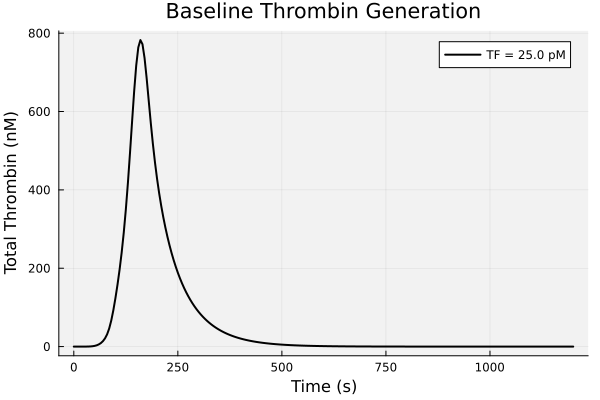

In [4]:
let
    # plot baseline thrombin generation curve -
    plot(t, thrombin_nM, xlabel="Time (s)", ylabel="Total Thrombin (nM)",
        label="TF = $(round(TF_baseline*1e12, digits=0)) pM", lw=2, color=:black,
        title="Baseline Thrombin Generation", background_color_inside=:gray95)
end

The baseline curve shows the three characteristic phases of thrombin generation: a lag phase where thrombin remains near zero while the initiation complex (TF:VIIa) activates small amounts of FXa and FIXa, a burst phase where the amplification loop (IXa:VIIIa and Xa:Va) drives rapid thrombin production, and a decay phase where antithrombin and other inhibitors terminate the response. Next, we explore how TF concentration controls these dynamics.
___

## Task 2: Explore TF Concentration Sensitivity
We sweep tissue factor concentration from 1 pM to 50 pM to observe how the initiator concentration controls the timing and magnitude of thrombin generation.

> __TF concentration and thrombin dynamics__
>
> Higher TF concentrations produce more TF:VIIa complex at the start of the cascade, which accelerates the initiation phase and shortens the lag time. The peak thrombin concentration also increases because more FXa is generated before TFPI can shut down the extrinsic pathway, allowing the amplification loop to engage earlier and more strongly.

We use [the `simulate(...)` function](https://github.com/varnerlab/HockinMannModel.jl/blob/main/src/Simulate.jl) and [the `total_thrombin(...)` function](https://github.com/varnerlab/HockinMannModel.jl/blob/main/src/Simulate.jl) to generate thrombin curves at each TF level. The TF concentrations are stored in `tf_values::Vector{Float64}` (molar) and the thrombin trajectories in `thrombin_matrix::Matrix{Float64}` (rows = time points, columns = TF levels, values in nM).

In [5]:
tf_values, thrombin_matrix = let

    # generate TF concentrations log-spaced from 1 pM to 50 pM -
    tf_values = 10 .^ range(log10(TF_min), log10(TF_max), length=n_TF_levels);

    # simulate at each TF level and collect thrombin curves -
    n_timepoints = length(t); # use baseline time vector length
    thrombin_matrix = zeros(Float64, n_timepoints, n_TF_levels);
    for (j, tf) in enumerate(tf_values)
        sol = HockinMannModel.simulate(HockinMann2002;
            TF_concentration = tf, tspan = tspan, saveat = saveat);
        thrombin_matrix[:, j] = HockinMannModel.total_thrombin(HockinMann2002, sol) .* 1e9; # M to nM
    end

    # return results -
    (tf_values, thrombin_matrix)
end;

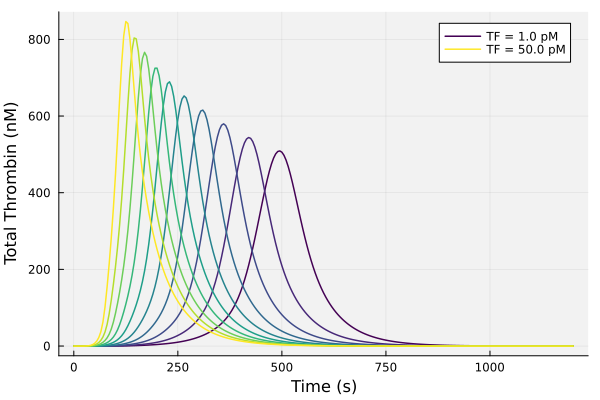

In [6]:
let
    # plot all curves colored by TF concentration -
    p = plot(xlabel="Time (s)", ylabel="Total Thrombin (nM)", legend=:topright,
        background_color_inside=:gray95);
    colors = palette(:viridis, n_TF_levels); # color gradient from low to high TF
    for j in 1:n_TF_levels
        label_str = (j == 1 || j == n_TF_levels) ?
            "TF = $(round(tf_values[j]*1e12, digits=1)) pM" : "";
        plot!(p, t, thrombin_matrix[:, j], label=label_str, color=colors[j], lw=1.5);
    end
    p
end

Higher TF concentrations shorten the lag phase, increase the peak thrombin, and shift the peak to earlier time points. At the lowest TF concentration (1 pM), the lag phase extends well past 400 seconds, while at 50 pM the burst phase begins almost immediately. TF concentration is the conditioning parameter used to train the Elman RNN in the companion example. Having explored TF, we now examine how coagulation factor levels modulate the cascade.
___

## Task 3: Explore Coagulation Factor Sensitivity
TF initiates the cascade, but coagulation factor levels determine how the cascade propagates and terminates. We vary three factors that represent different parts of the coagulation network: Factor VIII (amplification), antithrombin (termination), and Factor V (prothrombinase).

> __Coagulation factor roles__
>
> * **Factor VIII (FVIII):** cofactor for FIXa in the intrinsic tenase complex (IXa:VIIIa), which activates FX during the amplification phase. FVIII deficiency is the cause of Hemophilia A.
> * **Antithrombin (AT):** serine protease inhibitor that neutralizes thrombin (IIa), FXa, and FIXa. Low AT levels increase thrombotic risk.
> * **Factor V (FV):** cofactor for FXa in the prothrombinase complex (Xa:Va), which converts prothrombin to thrombin. FV deficiency reduces thrombin generation; the FV Leiden mutation (resistance to APC inactivation) is a common thrombophilia.

We use [the `percent_nominal_to_molar(...)` function](https://github.com/varnerlab/HockinMannModel.jl/blob/main/src/Simulate.jl) to convert clinical percent-of-normal values to molar concentrations and [the `patient_initial_conditions(...)` function](https://github.com/varnerlab/HockinMannModel.jl/blob/main/src/Simulate.jl) to set custom factor levels in the initial condition vector.

### Factor VIII (Amplification)
We sweep FVIII from 1% (severe Hemophilia A) to 150% (elevated) at a fixed TF concentration of 5 pM.

> __Hemophilia A__ is an X-linked bleeding disorder caused by deficiency of coagulation Factor VIII. It affects approximately 1 in 5,000 male births worldwide. 
> * Clinical severity correlates with FVIII activity level: severe (< 1%) patients experience spontaneous joint and muscle bleeds, moderate (1-5%) patients bleed after minor trauma, and mild (5-40%) patients bleed mainly after surgery or major injury. 
> * Treatment involves intravenous infusion of recombinant or plasma-derived FVIII concentrates, with prophylactic regimens now standard of care for severe patients. [Emicizumab](https://www.hemlibra.com/?adobe_mc=MCORGID%3DDF784CF658BD66380A495D3E%2540AdobeOrg%7CTS%3D1775474298&_gl=1*dbvq87*_gadup_aw*R0NMLjE3NzU0NzQyOTguQ2owS0NRandzODNPQmhENEFSSXNBQ2JsajE5M2Jyc1N6aG1VVzZ1STc0d0ttNHU2RHNRMW00OTZyX2RnZGJ1ZWF4ZzBqVHU2cGhGUm0zWWFBcDdYRUFMd193Y0I.*_gadup_dc*R0NMLjE3NzU0NzQyOTguQ2owS0NRandzODNPQmhENEFSSXNBQ2JsajE5M2Jyc1N6aG1VVzZ1STc0d0ttNHU2RHNRMW00OTZyX2RnZGJ1ZWF4ZzBqVHU2cGhGUm0zWWFBcDdYRUFMd193Y0I.*_gadup_ga*ODMyMDY2MDY3LjE3NzU0NzQyOTg.*_gadup_ga_9NC4Z86ZLS*czU5MDY2MDgxMTQzNzQ2NyRvMSRnMCR0MTc3NTQ3NDI5OSRqNTkkbDAkaDA.), a bispecific antibody that mimics FVIIIa cofactor function, has emerged as a subcutaneous alternative.

The thrombin curves are stored in `thrombin_fviii::Matrix{Float64}` (rows = time points, columns = FVIII levels, values in nM).

In [7]:
thrombin_fviii = let

    # simulate at each FVIII level -
    n_levels = length(fviii_levels);
    n_timepoints = length(t);
    thrombin_fviii = zeros(Float64, n_timepoints, n_levels);
    TF_fixed = 5e-12; # 5 pM TF for factor sweeps

    for (j, pct) in enumerate(fviii_levels)

        # convert percent-of-normal to molar -
        fviii_M = HockinMannModel.percent_nominal_to_molar(pct, :VIII);

        # build patient-specific initial conditions -
        u0 = HockinMannModel.patient_initial_conditions(HockinMann2002;
            TF = TF_fixed, VIII = fviii_M);

        # simulate and extract thrombin -
        sol = HockinMannModel.simulate(HockinMann2002;
            u0 = u0, tspan = tspan, saveat = saveat);
        thrombin_fviii[:, j] = HockinMannModel.total_thrombin(HockinMann2002, sol) .* 1e9; # M to nM
    end

    # return results -
    thrombin_fviii
end;

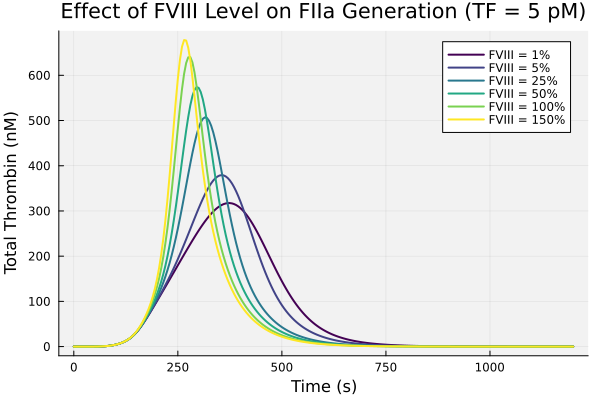

In [8]:
let
    # plot thrombin curves colored by FVIII level -
    n_levels = length(fviii_levels);
    colors = palette(:viridis, n_levels);
    p = plot(xlabel="Time (s)", ylabel="Total Thrombin (nM)",
        title="Effect of FVIII Level on FIIa Generation (TF = 5 pM)", legend=:topright,
        background_color_inside=:gray95);
    for j in 1:n_levels
        plot!(p, t, thrombin_fviii[:, j],
            label="FVIII = $(round(Int, fviii_levels[j]))%", color=colors[j], lw=2);
    end
    p
end

Severe FVIII deficiency (1%) produces minimal thrombin because the intrinsic tenase complex (IXa:VIIIa) cannot amplify FXa production. As FVIII increases, the peak grows and the lag time shortens. Above 100%, the effect saturates because FVIII is no longer rate-limiting.

### Antithrombin (Termination)
We sweep antithrombin from 50% (deficient, thrombophilia risk) to 150% (elevated) at 5 pM TF.

> __Antithrombin deficiency__ is an inherited clotting disorder carried on a non-sex chromosome (autosomal), where one defective copy of the antithrombin gene is enough to cause problems (dominant). It occurs in approximately 1 in 2,000 to 5,000 people, and accounts for 1-2% of patients presenting with [venous thromboembolism](https://en.wikipedia.org/wiki/Venous_thromboembolism) (VTE). 
> * Having one defective copy (heterozygous, 50-70% of normal AT) carries a 5-to-50-fold increased lifetime risk of VTE compared to the general population. 
> * Having both copies defective (homozygous) is incompatible with life. Management includes therapeutic anticoagulation (heparin, which requires AT as a cofactor, or direct oral anticoagulants) and AT concentrate infusion for acute events or surgical prophylaxis.

The thrombin curves are stored in `thrombin_at::Matrix{Float64}` (nM).

In [9]:
thrombin_at = let

    # simulate at each antithrombin level -
    n_levels = length(at_levels);
    n_timepoints = length(t);
    thrombin_at = zeros(Float64, n_timepoints, n_levels);
    TF_fixed = 5e-12; # 5 pM TF

    for (j, pct) in enumerate(at_levels)

        # convert percent-of-normal to molar -
        at_M = HockinMannModel.percent_nominal_to_molar(pct, :AT);

        # build patient-specific initial conditions -
        u0 = HockinMannModel.patient_initial_conditions(HockinMann2002;
            TF = TF_fixed, AT = at_M);

        # simulate and extract thrombin -
        sol = HockinMannModel.simulate(HockinMann2002;
            u0 = u0, tspan = tspan, saveat = saveat);
        thrombin_at[:, j] = HockinMannModel.total_thrombin(HockinMann2002, sol) .* 1e9; # M to nM
    end

    # return results -
    thrombin_at
end;

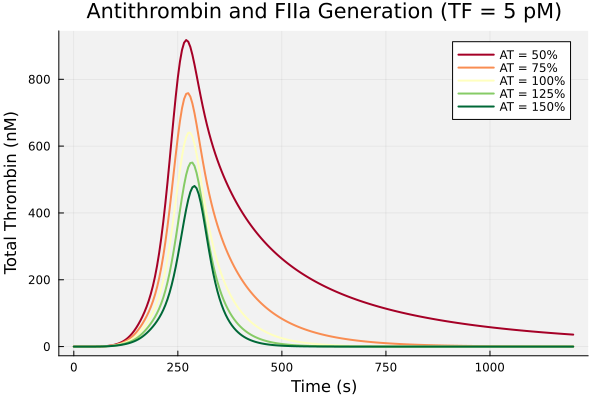

In [10]:
let
    # plot thrombin curves colored by AT level -
    n_levels = length(at_levels);
    colors = palette(:RdYlGn, n_levels); # red = low AT (risky), green = high AT
    p = plot(xlabel="Time (s)", ylabel="Total Thrombin (nM)",
        title="Antithrombin and FIIa Generation (TF = 5 pM)", legend=:topright,
        background_color_inside=:gray95);
    for j in 1:n_levels
        plot!(p, t, thrombin_at[:, j],
            label="AT = $(round(Int, at_levels[j]))%", color=colors[j], lw=2);
    end
    p
end

Low antithrombin produces higher and more sustained thrombin because FXa and thrombin are inhibited more slowly. This is the mechanism behind antithrombin deficiency as a risk factor for venous thromboembolism. Higher antithrombin reduces the peak and accelerates the decay phase.

### Factor V (Prothrombinase)
We sweep FV from 1% (severe deficiency) to 150% (elevated) at 5 pM TF.

> __Factor V deficiency__ (parahemophilia) is a rare autosomal recessive bleeding disorder with a prevalence of approximately 1 in 1,000,000. Severe deficiency (< 1%) causes mucocutaneous bleeding, epistaxis, and post-surgical hemorrhage. 
> 
> In contrast, __Factor V Leiden__ (a point mutation that makes FVa resistant to inactivation by activated protein C) is the most common inherited thrombophilia, present in approximately 5% of Caucasian populations. 
> 
> * FV Leiden heterozygotes have a 3-to-8-fold increased risk of venous thromboembolism. Treatment of FV deficiency relies on fresh frozen plasma (no FV concentrate is commercially available), while FV Leiden management focuses on anticoagulation during high-risk periods.

The thrombin curves are stored in `thrombin_fv::Matrix{Float64}` (nM).

In [11]:
thrombin_fv = let

    # simulate at each FV level -
    n_levels = length(fv_levels);
    n_timepoints = length(t);
    thrombin_fv = zeros(Float64, n_timepoints, n_levels);
    TF_fixed = 5e-12; # 5 pM TF

    for (j, pct) in enumerate(fv_levels)

        # convert percent-of-normal to molar -
        fv_M = HockinMannModel.percent_nominal_to_molar(pct, :V);

        # build patient-specific initial conditions -
        u0 = HockinMannModel.patient_initial_conditions(HockinMann2002;
            TF = TF_fixed, V = fv_M);

        # simulate and extract thrombin -
        sol = HockinMannModel.simulate(HockinMann2002;
            u0 = u0, tspan = tspan, saveat = saveat);
        thrombin_fv[:, j] = HockinMannModel.total_thrombin(HockinMann2002, sol) .* 1e9; # M to nM
    end

    # return results -
    thrombin_fv
end;

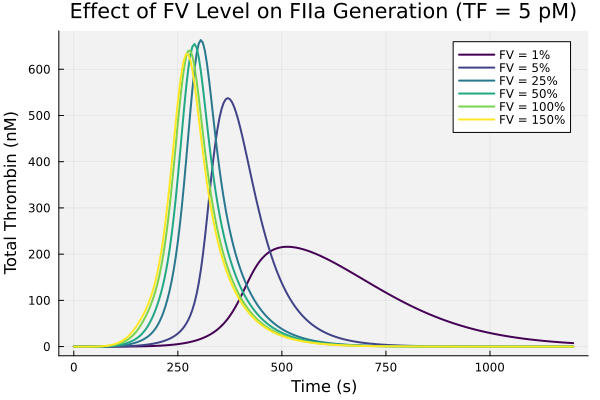

In [12]:
let
    # plot thrombin curves colored by FV level -
    n_levels = length(fv_levels);
    colors = palette(:viridis, n_levels);
    p = plot(xlabel="Time (s)", ylabel="Total Thrombin (nM)",
        title="Effect of FV Level on FIIa Generation (TF = 5 pM)", legend=:topright,
        background_color_inside=:gray95);
    for j in 1:n_levels
        plot!(p, t, thrombin_fv[:, j],
            label="FV = $(round(Int, fv_levels[j]))%", color=colors[j], lw=2);
    end
    p
end

FV deficiency reduces the prothrombinase complex (Xa:Va) activity, producing lower and delayed thrombin peaks. At 1% FV, thrombin generation is severely impaired because the prothrombinase complex is the final common pathway for thrombin production.

### TGA Features Summary Table
We compute thrombin generation assay (TGA) features for each factor variation and compare them in a summary table. The features are computed manually: peak thrombin from [the `maximum(...)` function](https://docs.julialang.org/en/v1/base/collections/#Base.maximum), time-to-peak from [the `argmax(...)` function](https://docs.julialang.org/en/v1/base/collections/#Base.argmax), and lag time as the first time point where thrombin exceeds the threshold. The results are stored in a `DataFrame` and displayed with [the `pretty_table(...)` function](https://ronisbr.github.io/PrettyTables.jl/stable/).

In [13]:
let

    rows = []; # collect table rows

    # helper: compute lag time as first time point where thrombin > threshold -
    function compute_lagtime(thrombin_vec, time_vec, threshold)
        idx = findfirst(x -> x > threshold, thrombin_vec);
        return idx === nothing ? NaN : time_vec[idx];
    end

    # --- FVIII sweep ---
    for (j, pct) in enumerate(fviii_levels)
        curve = thrombin_fviii[:, j];
        push!(rows, (
            Factor = "FVIII",
            Level_pct = round(Int, pct),
            Peak_nM = round(maximum(curve), digits=1),
            Tpeak_s = round(t[argmax(curve)], digits=0),
            Lagtime_s = round(compute_lagtime(curve, t, thrombin_lag_threshold), digits=0)
        ));
    end

    # --- Antithrombin sweep ---
    for (j, pct) in enumerate(at_levels)
        curve = thrombin_at[:, j];
        push!(rows, (
            Factor = "AT",
            Level_pct = round(Int, pct),
            Peak_nM = round(maximum(curve), digits=1),
            Tpeak_s = round(t[argmax(curve)], digits=0),
            Lagtime_s = round(compute_lagtime(curve, t, thrombin_lag_threshold), digits=0)
        ));
    end

    # --- FV sweep ---
    for (j, pct) in enumerate(fv_levels)
        curve = thrombin_fv[:, j];
        push!(rows, (
            Factor = "FV",
            Level_pct = round(Int, pct),
            Peak_nM = round(maximum(curve), digits=1),
            Tpeak_s = round(t[argmax(curve)], digits=0),
            Lagtime_s = round(compute_lagtime(curve, t, thrombin_lag_threshold), digits=0)
        ));
    end

    # display formatted table -
    df = DataFrame(rows);
    pretty_table(df;
        backend = :text,
        fit_table_in_display_horizontally = false,
        fit_table_in_display_vertically = false,
        table_format = TextTableFormat(borders = text_table_borders__simple),
        alignment = [:l, :r, :r, :r, :r]
    )
end

========= =========== ========= ========= ============
  Factor   Level_pct   Peak_nM   Tpeak_s   Lagtime_s 
  String       Int64   Float64   Float64     Float64 
========= =========== ========= ========= ============
  FVIII            1     317.4     375.0       120.0
  FVIII            5     379.2     355.0       120.0
  FVIII           25     507.0     315.0       120.0
  FVIII           50     573.9     295.0       120.0
  FVIII          100     640.2     280.0       120.0
  FVIII          150     677.9     265.0       120.0
  AT              50     917.4     270.0       110.0
  AT              75     758.5     275.0       115.0
  AT             100     640.2     280.0       120.0
  AT             125     550.6     285.0       130.0
  AT             150     480.6     290.0       135.0
  FV               1     215.9     515.0       280.0
  FV               5     537.5     370.0       210.0
  FV              25     663.1     305.0       155.0
  FV              50     654.5     290.0

The table quantifies the observations from the trajectory plots: FVIII deficiency reduces peak thrombin and extends the lag time, low antithrombin increases peak thrombin, and FV deficiency impairs prothrombinase activity and reduces thrombin generation.
___

## Summary
The Hockin-Mann 2002 coagulation model generates thrombin curves that vary systematically with tissue factor concentration and coagulation factor levels.

> __Key Takeaways:__
>
> * __TF concentration controls initiation timing and peak magnitude:__ Higher TF shortens the lag phase, increases peak thrombin, and shifts the peak to earlier time points by accelerating the formation of the TF:VIIa initiation complex.
> * __Coagulation factor levels modulate cascade propagation and termination:__ FVIII controls the amplification phase through the intrinsic tenase, FV controls the final common pathway through the prothrombinase complex, and antithrombin controls the termination phase by inhibiting thrombin and FXa.
> * __The coagulation model provides the training data for the Elman RNN:__ The parameter sweeps in this notebook demonstrate the range of dynamics that the RNN must learn to predict in the [companion example](CHEME-5820-L12a-Example-RNN-TimeSeries-Spring-2026.ipynb).

The sensitivity of the thrombin curve to factor levels and TF concentration establishes the data-generating process that the Elman RNN learns to approximate in the companion example.
___